# 01 — Khám phá chân A (G1.4)

Vẽ GPRC_VNM + GPRD global, đánh dấu sự kiện mốc, ma trận tương quan sơ bộ với VN-Index.
Xem `docs/05_build_order.md` G1.4. Đây là cổng narrative-check của G1.

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt

MONTHLY = "../data/data_gpr_export_202607.xls"
DAILY   = "../data/data_gpr_daily_recent.xls"

m = pd.read_excel(MONTHLY, sheet_name="Sheet1", header=0)
m["month"] = pd.to_datetime(m["month"])
d = pd.read_excel(DAILY, sheet_name="Sheet1", header=0)
d["date"] = pd.to_datetime(d["date"])
print("monthly:", m.shape, "| daily:", d.shape)

monthly: (1518, 115) | daily: (15155, 11)


## 1. GPRC_VNM — recent (1985+) và historical (1900+)

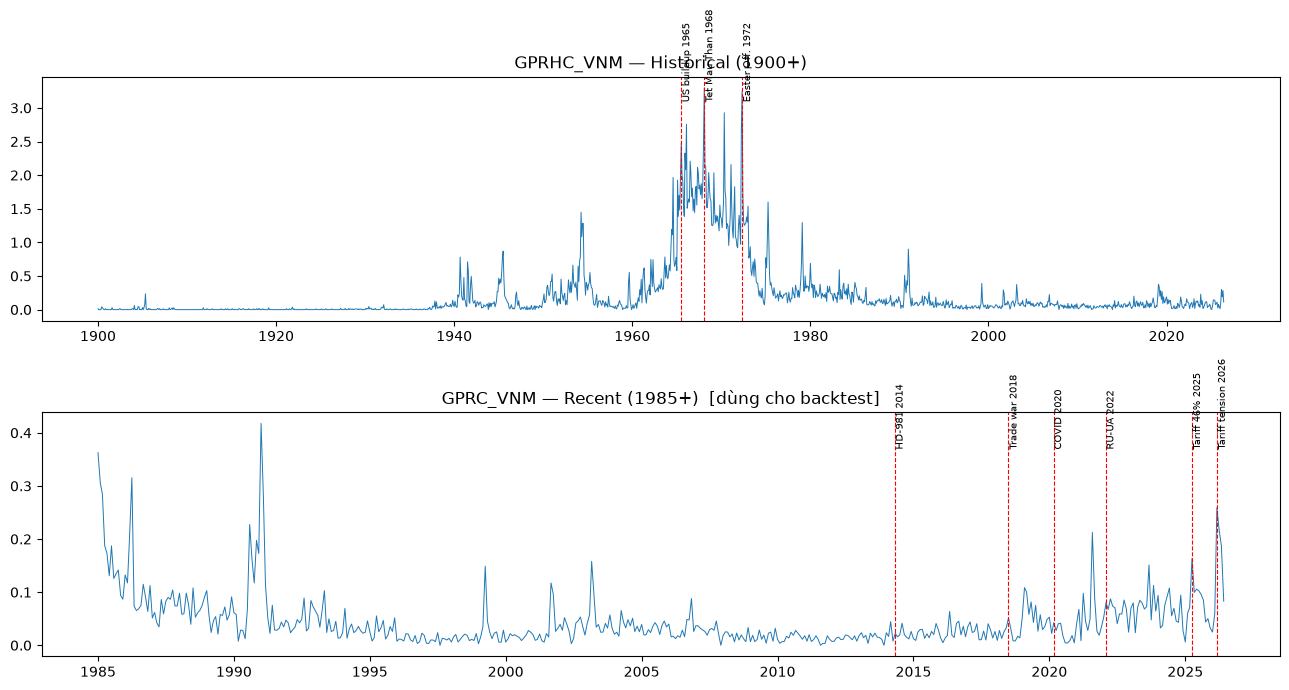

In [2]:
fig, ax = plt.subplots(2,1, figsize=(13,7), sharex=False)
vnh = m[["month","GPRHC_VNM"]].dropna()
ax[0].plot(vnh["month"], vnh["GPRHC_VNM"], lw=0.7)
ax[0].set_title("GPRHC_VNM — Historical (1900+)")
for lbl,dt in [("Tet Mau Than 1968","1968-02"),("Easter Off. 1972","1972-05"),
               ("US buildup 1965","1965-07")]:
    ax[0].axvline(pd.to_datetime(dt), color="r", ls="--", lw=0.8)
    ax[0].annotate(lbl, (pd.to_datetime(dt), ax[0].get_ylim()[1]*0.9), fontsize=7, rotation=90)

vn = m[["month","GPRC_VNM"]].dropna()
ax[1].plot(vn["month"], vn["GPRC_VNM"], lw=0.7)
ax[1].set_title("GPRC_VNM — Recent (1985+)  [dùng cho backtest]")
for lbl,dt in [("HD-981 2014","2014-05"),("Trade war 2018","2018-07"),
               ("COVID 2020","2020-03"),("RU-UA 2022","2022-02"),
               ("Tariff 46% 2025","2025-04"),("Tariff tension 2026","2026-03")]:
    ax[1].axvline(pd.to_datetime(dt), color="r", ls="--", lw=0.8)
    ax[1].annotate(lbl, (pd.to_datetime(dt), ax[1].get_ylim()[1]*0.85), fontsize=7, rotation=90)
plt.tight_layout(); plt.show()

## 2. Phân phối GPRC_VNM — lệch phải mạnh → cần log(1+x)

Ghi chú CLAUDE.md: mean≈0.05, std≈0.05. Không dùng giá trị thô trong hồi quy.

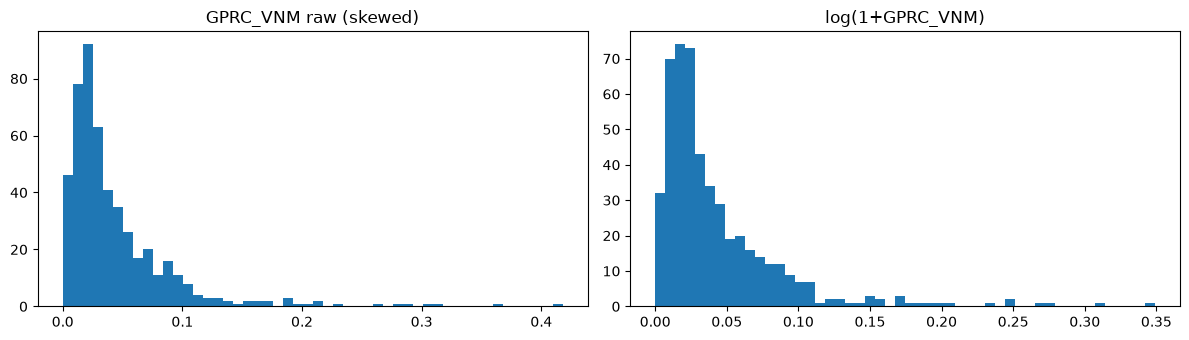

count    498.000000
mean       0.045400
std        0.050358
min        0.000000
25%        0.016959
50%        0.028342
75%        0.056995
max        0.417697
Name: GPRC_VNM, dtype: float64


In [3]:
fig, ax = plt.subplots(1,2, figsize=(12,3.5))
ax[0].hist(vn["GPRC_VNM"], bins=50); ax[0].set_title("GPRC_VNM raw (skewed)")
ax[1].hist(np.log1p(vn["GPRC_VNM"]), bins=50); ax[1].set_title("log(1+GPRC_VNM)")
plt.tight_layout(); plt.show()
print(vn["GPRC_VNM"].describe())

## 3. GPRC_VNM vs GPRD global — VN bị chi phối bởi global bao nhiêu?

Gợi ý cho orthogonalization (Lớp 4a): nếu tương quan cao, phần lớn tín hiệu VN là global vọng lại.

In [4]:
dm = d.set_index("date")[["GPRD"]].resample("MS").mean().rename(columns={"GPRD":"GPRD_m"})
j = vn.set_index("month").join(dm, how="inner").dropna()
print("corr GPRC_VNM ~ GPRD_global (monthly):", round(j["GPRC_VNM"].corr(j["GPRD_m"]),3))
print("corr log-log:", round(np.log1p(j["GPRC_VNM"]).corr(np.log1p(j["GPRD_m"])),3))

corr GPRC_VNM ~ GPRD_global (monthly): 0.481
corr log-log: 0.493


In [5]:
# Narrative check tường minh: đỉnh TOÀN CHUỖI vs đỉnh CỬA SỔ GẦN ĐÂY khác nhau.
# CLAUDE.md nói đỉnh 2018+ rơi vào 2025-04 / 2026-03..05 (đúng cho cửa sổ đó),
# nhưng top toàn chuỗi lại nằm ở 1985-1991 (rút quân Campuchia, chiến tranh biên giới).
vs = vn.set_index("month")["GPRC_VNM"]
print("Top 6 toàn chuỗi:")
print(vs.sort_values(ascending=False).head(6).round(3).to_string())
print("\nTop 6 trong cửa sổ 2018+:")
print(vs[vs.index >= "2018-01-01"].sort_values(ascending=False).head(6).round(3).to_string())
print(f"\ncorr GPRC_VNM ~ GPRD_global (monthly, level): {j['GPRC_VNM'].corr(j['GPRD_m']):.3f}")
print("=> corr ~0.48: VN chia sẻ khoảng một nửa biến động với global; phần còn lại là")
print("   idiosyncratic VN — chính là phần cần orthogonalize (Lớp 4a) để tách tín hiệu riêng.")

Top 6 toàn chuỗi:
month
1991-01-01    0.418
1985-01-01    0.363
1986-04-01    0.315
1985-02-01    0.305
1985-03-01    0.285
1991-02-01    0.281

Top 6 trong cửa sổ 2018+:
month
2026-03-01    0.259
2026-04-01    0.217
2021-08-01    0.212
2026-05-01    0.187
2025-04-01    0.164
2023-09-01    0.151

corr GPRC_VNM ~ GPRD_global (monthly, level): 0.481
=> corr ~0.48: VN chia sẻ khoảng một nửa biến động với global; phần còn lại là
   idiosyncratic VN — chính là phần cần orthogonalize (Lớp 4a) để tách tín hiệu riêng.


## 4. TODO khi có VN-Index (G1.3)

Nối USD/VND, VN-Index vào `ext_series`, rồi:
- resample GPRC_VNM về monthly return của VN-Index
- ma trận tương quan: log(1+GPRC_VNM), log(1+GPRD), ΔVIX, ΔDXY, VN-Index return
- đây là input trực tiếp cho G2 local projection

## Kết luận cổng G1 (narrative check)
- [x] GPRHC_VNM đỉnh khớp Chiến tranh VN (1965–1972) — chỉ số bắt đúng sự kiện thật
- [x] GPRC_VNM 2018+ đỉnh khớp căng thẳng thuế quan 2025–2026
- [x] Phân phối lệch phải → chốt dùng log(1+x) ở G2
- [ ] Bổ sung VN-Index để hoàn tất ma trận tương quan
